# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## 5.1 Plastic film folding machine

On a machine that folds plastic film the temperature may be varied in the range of 130-185 °C. For obtaining, if possible, a model for the influence of temperature on the folding thickness, $n = 12$ related set of values of temperature and the fold thickness were measured, illustrated by a scatter plot of temperature (130-180) against thickness (90-130).

### a)
Determine by looking at the figure, which of the following sets of estimates for the parameters in the usual regression model is correct:

1) $\hat{\beta}_0 = 0$, $\hat{\beta}_1 = -0.9$, $\hat{\sigma} = 36$
2) $\hat{\beta}_0 = 0$, $\hat{\beta}_1 = 0.9$, $\hat{\sigma} = 3.6$
3) $\hat{\beta}_0 = 252$, $\hat{\beta}_1 = -0.9$, $\hat{\sigma} = 3.6$
4) $\hat{\beta}_0 = -252$, $\hat{\beta}_1 = -0.9$, $\hat{\sigma} = 36$
5) $\hat{\beta}_0 = 252$, $\hat{\beta}_1 = -0.9$, $\hat{\sigma} = 36$

**Solution:**

Looking at the figure it apprears that $\hat{\beta}_0 = 252$, $\hat{\beta}_1 = -0.9$, $\hat{\sigma} = 3.6$ is the correct answer,

on the plot we see: 
$x=130,y \approx 133; \text{at } x=185,y \approx 84$ 

### b)
What is the only possible correct answer:

1) The proportion of explained variation is 50% and the correlation is 0.98
2) The proportion of explained variation is 0% and the correlation is $-0.98$
3) The proportion of explained variation is 96% and the correlation is $-1$
4) The proportion of explained variation is 96% and the correlation is 0.98
5) The proportion of explained variation is 96% and the correlation is $-0.98$

**Solution:**
Looking at the figure, the points lie very close to the red line, so the proportion of explained variation ($R^2$) must be high, which rules out options 1 and 2 (50% and 0%).

Since $\hat{\beta}_1 = -0.9 < 0$ (from part a), the correlation must be negative, using $\hat{\rho} = \sqrt{R^2} \cdot \text{sign}(\hat{\beta}_1)$. This rules out option 4 (positive correlation).

A correlation of exactly $-1$ would mean a perfect linear relationship with zero scatter, but there is clearly some scatter around the line. This rules out option 3.

This leaves option 5: the proportion of explained variation is 96% and the correlation is $-0.98$, which is consistent since $\sqrt{0.96} \approx 0.98$.

## 5.2 Linear regression life time model

A company manufactures an electronic device to be used in a very wide temperature range. The company knows that increased temperature shortens the life time of the device, and a study is therefore performed in which the life time is determined as a function of temperature. The following data is found:

| Temperature in Celsius (t) | 10 | 20 | 30 | 40 | 50 | 60 | 70 | 80 | 90 |
|---|---|---|---|---|---|---|---|---|---|
| Life time in hours (y) | 420 | 365 | 285 | 220 | 176 | 117 | 69 | 34 | 5 |

In this exercise you should use Python for computations, data visualization etc.

### a)
Analyse the relationship between Temperature and Life time (including data visualization and estimation of parameters in a relevant statistical model).

**Solution:**
The regression equation is $\hat{y} = 453.56 - 5.31t$, meaning lifetime decreases by about 5.31 hours for each 1°C increase in temperature. With $R^2 = 0.984$, temperature explains 98.4% of the variation in lifetime, and the very small p-value ($1.51 \times 10^{-7}$) indicates a highly significant linear relationship.

However, the residual plot shows a clear U-shaped pattern (positive residuals at low and high temperatures, negative in the middle), suggesting the relationship may not be perfectly linear and a curved model could fit better.

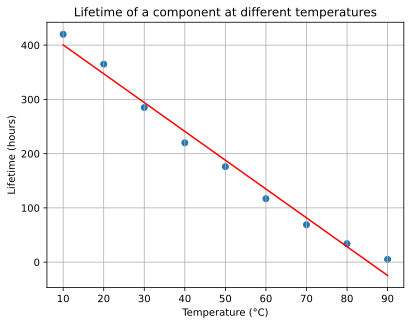

Regression equation: y = 453.56 + -5.31*t
R² = 0.9840
p-value = 1.5050e-07
Std error = 0.2558
Residual standard deviation (σ) = 19.8128


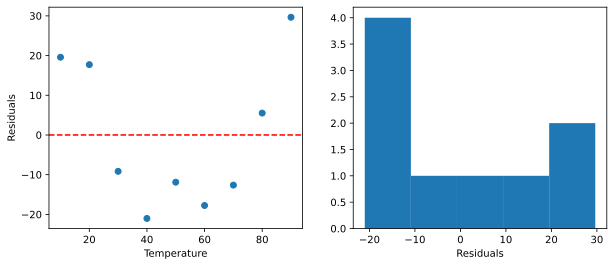

In [2]:
temp = np.array([10,20,30,40,50,60,70,80,90])

lifetime = np.array([420,365,285,220,176,117,69,34,5])

dataframe = pd.DataFrame({'temp': temp, 'lifetime': lifetime})

plt.scatter(dataframe['temp'], dataframe['lifetime'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Lifetime (hours)')
plt.title('Lifetime of a component at different temperatures')
plt.grid()

slope, intercept, r_value, p_value, std_err = stats.linregress(temp, lifetime)
plt.plot(dataframe['temp'], intercept + slope * dataframe['temp'], color='red')
plt.show()

residuals = lifetime - (intercept + slope * temp)
print(f"Regression equation: y = {intercept:.2f} + {slope:.2f}*t")
print(f"R² = {r_value**2:.4f}")
print(f"p-value = {p_value:.4e}")
print(f"Std error = {std_err:.4f}")
residual_std = np.sqrt(np.sum(residuals**2) / (len(temp) - 2))
print(f"Residual standard deviation (σ) = {residual_std:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(temp, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Temperature')
plt.ylabel('Residuals')
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=5)
plt.xlabel('Residuals')
plt.show()

### b)
Compute a 95% confidence interval for the slope in the linear regression model.

**Solution:**

In [3]:
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=len(temp)-2)

ci_lower = slope - t_crit * std_err
ci_upper = slope + t_crit * std_err
print(f"95% CI for slope: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI for slope: [-5.9182, -4.7085]


### c)
Can a relation between temperature and life time be documented on level 5%?

**Solution:**
We already found the p-value in part a). It was found to be $1.505 \times 10^{-7}$, testing
$$H_0: \beta_1 = 0 \quad \text{vs.} \quad H_1: \beta_1 \neq 0$$
Since the p-value is much smaller than $\alpha = 0.05$, we reject the null hypothesis and conclude that there is a statistically significant relationship between temperature and life time at the 5% significance level.

### d)
Estimate the linear regression model using Python's inbuilt function `fit = smf.ols(...).fit()`. Compare the output table with your own results (print the output table in Python using `print(fit.summary(slim=True))`. Can you find the parameter estimates, their standard errors, confidence intervals and the corresponding test statistics and p-values? Make sure you understand what these p-values represent).

**Solution:**

- $\hat\beta_0 = 453.56$ (Intercept) and $\hat\beta_1 = -5.31$ (temp) match our estimates from part a).
- The standard errors (`std err` column) match $\hat\sigma_{\beta_0}$ and $\hat\sigma_{\beta_1}$.
- The `[0.025, 0.975]` columns give the 95% confidence intervals, matching our result from part b): $[-5.918, -4.709]$ for the slope.
- The `t` and `P>|t|` columns give the test statistic and p-value for $H_0: \beta_i = 0$. For `temp`, P>|t| = 0.000 confirms the significant relationship found in part c).

Each row's p-value tests whether that particular parameter is significantly different from zero, holding the model as specified.

In [4]:
fit = smf.ols('lifetime ~ temp', data=dataframe).fit()
print(fit.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:               lifetime   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.982
No. Observations:                   9   F-statistic:                     431.5
Covariance Type:            nonrobust   Prob (F-statistic):           1.51e-07
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    453.5556     14.394     31.511      0.000     419.520     487.591
temp          -5.3133      0.256    -20.773      0.000      -5.918      -4.709

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


## 5.4 Plastic material

In the manufacturing of a plastic material, it is believed that the cooling time has an influence on the impact strength. Therefore a study is carried out in which plastic material impact strength is determined for 4 different cooling times. The results of this experiment are shown in the following table:

| Cooling times in seconds (x) | 15 | 25 | 35 | 40 |
|---|---|---|---|---|
| Impact strength in kJ/m$^2$ (y) | 42.1 | 36.0 | 31.8 | 28.7 |

The following statistics may be used:

$$\bar{x} = 28.75, \quad \bar{y} = 34.65, \quad S_{xx} = 368.75.$$

### a)
What is the 95% confidence interval for the slope of the regression model, expressing the impact strength as a linear function of the cooling time?

**Solution:**

### b)
Can you conclude that there is a relation between the impact strength and the cooling time at significance level $\alpha = 5\%$?

**Solution:**

### c)
For a similar plastic material the tabulated value for the linear relation between temperature and impact strength (i.e the slope) is $-0.30$. If the following hypothesis is tested (at level $\alpha = 0.05$)

$$H_0 : \beta_1 = -0.30$$
$$H_1 : \beta_1 \neq -0.30$$

with the usual t-test statistic for such a test, what is the range (for t) within which the hypothesis is accepted?

**Solution:**

## 5.5 Water polution

In a study of pollution in a water stream, the concentration of pollution is measured at 5 different locations. The locations are at different distances to the pollution source. In the table below, these distances and the average pollution are given:

| Distance to the pollution source (in km) | 2 | 4 | 6 | 8 | 10 |
|---|---|---|---|---|---|
| Average concentration | 11.5 | 10.2 | 10.3 | 9.68 | 9.32 |

### a)
What are the parameter estimates for the three unknown parameters in the usual linear regression model: 1) The intercept ($\beta_0$), 2) the slope ($\beta_1$) and 3) error standard deviation ($\sigma$)?

**Solution:**

### b)
How large a part of the variation in concentration can be explained by the distance?

**Solution:**

### c)
What is a 95%-confidence interval for the expected pollution concentration 7 km from the pollution source?

**Solution:**

## E9.15 t-test parametrization

### a)
Assuming that $Y_{1,i} \sim N(\mu_1, \sigma^2)$ and $Y_{2,j} \sim N(\mu_2, \sigma^2)$ are iid and $i \in \{1, ..., n_1\}$ and $j \in \{1, ..., n_2\}$ formulate an LM (i.e. parametrize $X$)

$$Y = X\beta + \epsilon; \quad \epsilon \sim N(0, \sigma^2 I) \tag{9-11}$$

with

$$Y = \begin{bmatrix} Y_1 \\ Y_2 \end{bmatrix}; \quad X = \begin{bmatrix} 1_{n_1} & a 1_{n_1} \\ 1_{n_2} & b 1_{n_2} \end{bmatrix} \tag{9-12}$$

such that the parametrization is orthogonal and $\hat{\beta}_1 = \frac{1}{n_1+n_2}(n_1\bar{Y}_1 + n_2\bar{Y}_2)$, i.e. the average of all observations, and $\hat{\beta}_2 = \bar{Y}_1 - \bar{Y}_2$.

**Solution:**